In [1]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict,Any,Annotated
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field
from operator import add

c:\Users\ACER\OneDrive\Desktop\MACHINE LEARNING\Langraph\myvenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
llm_groq=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.4
)

In [3]:
class EvaluationSchema(BaseModel):
    score:int=Field(description="score out of 10",ge=0,le=10)
    comments:list[str]=Field(description="list of feedback points")

In [4]:
structured_llm=llm_groq.with_structured_output(EvaluationSchema)

In [5]:
class EssayState(TypedDict):
    essay_input:str
    language:Any
    analysis:Any
    structure:Any
    originality:Any

In [6]:
def check_language(state:EssayState)->dict:
    essay=state["essay_input"]
    prompt=f"""Evaluate LANGUAGE QUALITY: grammar, clarity, sentence flow, readability, vocabulary.
Ignore argument quality, structure, ideas.
Essay:
{essay}"""
    return {"language":structured_llm.invoke(prompt)}

In [7]:
def check_depth(state:EssayState)->dict:
    essay=state["essay_input"]
    prompt=f"""Evaluate DEPTH OF ANALYSIS: multidimensional thinking, reasoning, examples, understanding.
Penalize superficial description. Ignore language and structure.
Essay:
{essay}"""
    return {"analysis":structured_llm.invoke(prompt)}

In [8]:
def check_structure(state:EssayState)->dict:
    essay=state["essay_input"]
    prompt=f"""Evaluate STRUCTURE & COHERENCE: introduction, logical flow, transitions, conclusion.
Ignore grammar and idea quality.
Essay:
{essay}"""
    return {"structure":structured_llm.invoke(prompt)}

In [9]:
def check_originality(state:EssayState)->dict:
    essay=state["essay_input"]
    prompt=f"""Evaluate ORIGINALITY & CRITICAL THINKING: unique perspective, balance, counterarguments, maturity.
Penalize generic content. Ignore grammar and structure.
Essay:
{essay}"""
    return {"originality":structured_llm.invoke(prompt)}

In [10]:
graph=StateGraph(EssayState)

graph.add_node("check_language",check_language)
graph.add_node("check_analysis",check_depth)
graph.add_node("check_structure",check_structure)
graph.add_node("check_originality",check_originality)

graph.add_edge(START,"check_language")
graph.add_edge(START,"check_analysis")
graph.add_edge(START,"check_structure")
graph.add_edge(START,"check_originality")

graph.add_edge("check_language",END)
graph.add_edge("check_analysis",END)
graph.add_edge("check_structure",END)
graph.add_edge("check_originality",END)

workflow=graph.compile()

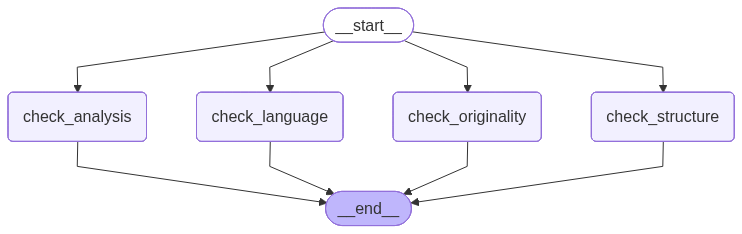

In [11]:
workflow

In [12]:
input_state={"essay_input":"""Technology as the Silent Architect of Human Destiny

Human history has often been narrated through kings, wars, and revolutions, yet beneath these visible events lies an invisible force quietly shaping civilizations — technology..."""}

output_state=workflow.invoke(input_state)

In [14]:
output_state

{'essay_input': 'Technology as the Silent Architect of Human Destiny\n\nHuman history has often been narrated through kings, wars, and revolutions, yet beneath these visible events lies an invisible force quietly shaping civilizations — technology...',
 'language': EvaluationSchema(score=9, comments=['Excellent use of vocabulary', 'Clear and concise sentence structure', 'Good flow and readability', 'Effective use of metaphors', 'Minor suggestions for improvement in sentence variation']),
 'analysis': EvaluationSchema(score=8, comments=["The essay provides a good introduction to the topic of technology's impact on human history", 'It attempts to delve beyond superficial descriptions of historical events', 'However, the analysis could be more multidimensional, incorporating specific examples and case studies to support the argument', 'Additionally, the essay could benefit from a clearer structure and more nuanced reasoning to elevate the depth of analysis']),
 'structure': EvaluationSche

In [16]:
print(f"Language: {output_state['language'].score}/10, \n{output_state['language'].comments}")
print(f"Analysis: {output_state['analysis'].score}/10, \n{output_state['analysis'].comments}")
print(f"Structure: {output_state['structure'].score}/10, \n{output_state['structure'].comments}")
print(f"Originality: {output_state['originality'].score}/10, \n{output_state['originality'].comments}")

Language: 9/10, 
['Excellent use of vocabulary', 'Clear and concise sentence structure', 'Good flow and readability', 'Effective use of metaphors', 'Minor suggestions for improvement in sentence variation']
Analysis: 8/10, 
["The essay provides a good introduction to the topic of technology's impact on human history", 'It attempts to delve beyond superficial descriptions of historical events', 'However, the analysis could be more multidimensional, incorporating specific examples and case studies to support the argument', 'Additionally, the essay could benefit from a clearer structure and more nuanced reasoning to elevate the depth of analysis']
Structure: 8/10, 
['Clear introduction that sets the tone for the essay', 'Effective use of transitions to connect ideas is not fully evident in this partial essay', 'Logical flow is present but may need further development throughout the essay', 'Conclusion is not present in this partial essay']
Originality: 8/10, 
['The essay offers a unique p